# Experiment 4: Threshold

In this experiment, we will use the best model (dual embeddings of the chunks and the metadata of the whole document) and find the optimal threshold for cosine similarity.

In [1]:
import json
from pathlib import Path
import fitz #pip install PyMuPDF

from embedder import Embedder

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
BASE_DIR = Path.cwd().parents[0]   # backend/
PDF_EXAMPLES = BASE_DIR/ "example_pdfs_to_upload"

DATA_DIR = BASE_DIR / "data"
META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"
LLM_CHUNKS_PATH = BASE_DIR / "llm_database.json" #ATATA CAMBIAR A DATA??

if not META_CACHE_PATH.exists():
    raise RuntimeError("llm_metadata_cache.json not found. Metadata must be precomputed.")

with META_CACHE_PATH.open("r", encoding="utf-8") as f:
    metadata_cache = json.load(f)

In [3]:
def build_metadata_string(llm_meta):

    if not llm_meta:
        return ""
    parts = []
    if llm_meta.get("title"):
        parts.append(f"Title: {llm_meta['title']}")
    if llm_meta.get("topics"):
        parts.append("Topics: " + ", ".join(llm_meta["topics"]))
    if llm_meta.get("keywords"):
        parts.append("Keywords: " + ", ".join(llm_meta["keywords"]))
    if llm_meta.get("one_sentence_summary"):
        parts.append("Summary: " + llm_meta["one_sentence_summary"])
    return "[METADATA]\n" + "\n".join(parts)

def get_llm_metadata(pdf_name: str) -> dict:
    """
    Read-only metadata accessor.
    No LLM calls. No side effects.
    """
    return metadata_cache.get(pdf_name, {})

In [4]:
class DataManager:
    """
    Handles:
    - PDF text extraction
    - Chunking
    - Embedding dual
    """

    def __init__(self, pdf_folder, llm_db_path = LLM_CHUNKS_PATH):
        self.embedder = Embedder()
        self.pdf_folder = pdf_folder
        self.tokenizer = self.embedder.model.tokenizer
        
        with open(llm_db_path, "r", encoding="utf-8") as f:
            llm_db = json.load(f)  

        self.llm_chunks_map = {
            d["pdf_name"]: d.get("chunks", [])  
            for d in llm_db
            if "pdf_name" in d
}
    
    # ------------------------------
    # PDF TEXT EXTRACTION
    # ------------------------------
    def extract_text(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = "".join(page.get_text() for page in doc)
        doc.close()
        return text

    # ------------------------------
    # CHUNKING
    # ------------------------------
    
    def get_llm_chunks(self, pdf_name):
        chunks = self.llm_chunks_map.get(pdf_name, [])
        if not chunks:
            raise ValueError(f"No LLM chunks found for {pdf_name} in llm_database.json")
        return chunks

    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path):
        chunks_from_json = self.get_llm_chunks(pdf_path.name)
        chunks = [c['text'] for c in chunks_from_json]

        llm_meta = get_llm_metadata(pdf_path.name)
        meta_str = build_metadata_string(llm_meta)
        emb_meta = self.embedder.encode(meta_str)

        chunk_records = []
        for chunk in chunks:
            emb_text = self.embedder.encode(chunk)
            chunk_records.append({
                "text": chunk,
                "embedding_text": emb_text,
                "embedding_meta": emb_meta
            })

        return {
            "pdf_name": pdf_path.name,
            "llm_metadata": llm_meta,
            "chunks": chunk_records}

    # ------------------------------
    # INDEX BUILDING
    # ------------------------------
    def build_index(self, pdf_paths):
        database = []

        for pdf_path in pdf_paths:
            entry = self.process_pdf(pdf_path)
            print(f"Indexed: {pdf_path.name}")
            database.append(entry)

        return database

In [5]:
import numpy as np

class BaselineRetriever:
    def __init__(self, database=None, embedder=None):
        self.embedder = embedder or Embedder()
        self.database = database or []

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70, alpha=0.7):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = 0.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                s_text = self.cosine_similarity(query_emb, chunk["embedding_text"])
                s_meta = self.cosine_similarity(query_emb, chunk["embedding_meta"])
                score = alpha * s_text + (1 - alpha) * s_meta

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name", "")),
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk["text"][:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results

In [7]:
embedder = Embedder()
dm = DataManager(pdf_folder=PDF_EXAMPLES)
pdf_paths = list(PDF_EXAMPLES.glob("*.pdf"))

final_model_db = dm.build_index(pdf_paths)
final_retriever = BaselineRetriever(final_model_db, embedder)

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

### 2. Evaluation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
queries_easy = {
    "GDPR compliance and neuroimaging data privacy": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "bottleneck fusion for multimodal medical data integration": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory clinical metrics for alzheimers disease classification": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "tau protein biomarkers and hippocampal atrophy correlation": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "hyperparameter sweep and weights and biases tracking": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "docker environment setup for local hardware clusters": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "synthetic data generation and smote for class imbalance": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "weekly team sync and tau protein data audit": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "scaled dot product attention mechanism": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "deep residual learning for image recognition": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "vision transformer using image patches": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "retrieval augmented generation for nlp tasks": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adam optimizer for stochastic optimization": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "taxonomy of multimodal machine learning": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "pathological network model for alzheimers interventions": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "graph model of tau pathology spreading": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "personalized trajectories of cortical atrophy": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "pathology steered stratification for subtype identification": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "video reasoning over traffic events benchmark": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "deep counterfactuals for alzheimers prediction": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "multimodal attention for disease diagnosis": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "evaluating disease focus in deep learning models": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "explainable ai requirements for clinicians": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "transfer learning for 3d medical image analysis": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "generative adversarial networks in medical imaging review": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "success factors for scientific teams": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "monetary value of large scientific collaboration": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher perceptions of llm tools": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [13]:
queries_intermediate = {
    "distinction between pseudonymization and anonymization under gdpr": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "kl divergence for latent space regularization": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "area under the precision recall curve for imbalanced data": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "k-nearest neighbors imputation for missing tau protein values": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "optimal batch size and learning rate interaction in adamw": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "solving numpy and scipy version mismatch for linear algebra": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "elastic transformations for simulating anatomical variability": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "dynamic masking for incomplete multimodal inputs": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "multi-head self-attention and position-wise feed-forward networks": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "shortcut connections and identity mapping for optimization": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "transformer encoder blocks for fine-grained image recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "knowledge-intensive tasks using dense vector retrieval": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adaptive moment estimation mechanics for deep learning": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "challenges in cross-modal alignment and feature fusion": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "combinatorial intervention strategies for alzheimers networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot inverse solver for two-species graph models": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "spatiotemporal modeling of cortical atrophy trajectories": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "subtype identification in alzheimers using stratification networks": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "efficient networks for temporal reasoning in video": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "interpretable volumetric changes using deep counterfactuals": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "attention weights for integrating imaging and clinical data": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "quantitative metrics for disease focus and saliency maps": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinical requirements for explainable ai decision support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical imaging analysis using pre-trained med3d models": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "gan applications for medical image synthesis and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "link between scientific team freshness and success": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "productivity estimates of large scale scientific collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "large scale survey of researcher usage of llms": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [14]:
queries_difficult = {
    "unauthorized data transfer to neurocloud analytic solutions": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "intermediate fusion vs early fusion for 3d mri data": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory external validation using oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "missing tau protein data for subjects ad-102 to ad-118": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "mri encoder overfitting patterns starting at epoch 50": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "cuda 12.1 and pytorch 2.4.0 cluster requirements": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "parameters for bob's elastic transform alpha 50 and sigma 8": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "audit of pet-tau tracers for 24-month follow-up window": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "square root of dk scaling factor in attention": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "convergence of stochastic gradient descent in deep residuals": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "16x16 pixel image patch size for transformer recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "parametric generator and non-parametric retriever synergy": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "bias correction using first and second moment estimates": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "co-learning and modality representation mismatch": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "dynamic interventions in pathological protein networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot solver for graph models of neurodegeneration": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "longitudinal modeling of atrophy in alzheimers patient cohorts": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "stratification network performance across diverse alzheimers subtypes": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "temporal reasoning benchmarks for traffic event qa": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "quantitative interpretation of brain region volumetric changes": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "integrated analysis of pet scans and clinical cognitive scores": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "saliency map evaluation and disease relevant features": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinician centered explainable ai for critical care support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical analysis using transfer learning on large scale datasets": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "adversarial training for medical image segmentation and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "scientific team success through fresh perspectives": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "economic analysis of scientific productivity in large collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher tool usage and perceptions survey results": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [25]:
queries_negative = {
    "Clinical efficacy of Aducanumab in phase 3 trials": None,
    "Using Kubernetes for GPU orchestration in medical clusters": None,
    "Impact of Vitamin E on cognitive decline in late-stage dementia": None,
    "Training Llama 3 on private patient medical records": None,
    "Deploying models to AWS SageMaker via Terraform scripts": None,
    "Real-time patient monitoring using wearable IoT devices for Parkinson's": None,
    "HIPAA-compliant data storage in California state clouds": None,
    "Genetic markers for Type 2 Diabetes in European cohorts": None,
    "Comparing YOLOv10 performance on surgical video feeds": None,
    "Using Gated Recurrent Units (GRU) for temporal cognitive modeling": None,
    "Financial audit of the 2024 neuro-oncology grant": None,
    "Impact of Mediterranean diet on hippocampal volume": None,
    "Setting up a Slurm cluster for distributed training on A100 GPUs": None,
    "Using GANs to generate synthetic chest X-rays for pneumonia": None,
    "Analysis of the impact of sleep apnea on Amyloid-beta clearance": None,
    "Comparison between ResNet-101 and DenseNet-201 for skin lesion classification": None,
    "Managing clinical trials through the 'Medidata Rave' platform": None,
    "Protocols for lumbar puncture in pediatric neurology": None,
    "Using Reinforcement Learning from Human Feedback (RLHF) for medical chatbots": None,
    "The role of Apolipoprotein E (APOE) ε2 allele in longevity": None,
    "Building a data lake on Google Cloud Storage (GCS) for genomics": None,
    "Evaluation of the 'Mini-Mental State Exam' (MMSE) scores in healthy teenagers": None,
    "Using Graph Convolutional Networks (GCN) for modeling chemical toxicity": None,
    "Integrating the 'MIMIC-IV' dataset into the AD-Fusion pipeline": None,
    "Ethical guidelines for using brain-computer interfaces in sports": None,
    "Using Apache Spark for distributed preprocessing of genomic VCF files": None,
    "The effect of caffeine consumption on Tau-protein phosphorylation": None,
    "Training Vision Transformers (ViT) on the ImageNet-21k dataset": None
}

In [20]:
def reciprocal_rank(results, target_doc):
    for i, r in enumerate(results):
        if r["pdf_name"] == target_doc:
            return 1.0 / (i + 1)
    return 0.0

In [21]:
def hit_at_k(results, target_doc, k=3):
    return int(any(r["pdf_name"] == target_doc for r in results[:k]))

In [ ]:
def evaluate_query_set(retriever, queries, threshold, k=3):
    """
    queries:
      - positive: dict[query -> target_doc]
      - negative: dict[query -> None]
    """

    TP = FP = FN = TN = 0
    mrrs = []
    hits = []

    for query, target in queries.items():
        results = retriever.search(query, threshold=threshold)
        top_k = results[:k]

        # Negative query
        if target is None:
            if len(results) > 0:
                FP += 1
            else:
                TN += 1
            continue

        # Positive query
        rr = reciprocal_rank(results, target)
        hit = hit_at_k(results, target, k)

        mrrs.append(rr)
        hits.append(hit)

        if hit == 1:
            TP += 1
        else:
            FN += 1

    return {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "MRR": sum(mrrs) / len(mrrs) if mrrs else 0.0,
        "Hit@3": sum(hits) / len(hits) if hits else 0.0,
        "Precision": TP / (TP + FP) if (TP + FP) else 0.0,
        "Recall": TP / (TP + FN) if (TP + FN) else 0.0,
        "FPR": FP / (FP + TN) if (FP + TN) else 0.0,
    }


In [60]:
def sweep_thresholds(retriever, thresholds, query_sets):
    rows = []
    for t in thresholds:
        if (t*100)%2 == 0:
            print(f"{int(t*100)}% processed...")
        for name, queries in query_sets.items():
            metrics = evaluate_query_set(retriever, queries, threshold=t)
            rows.append({
                "Threshold": t,
                "QuerySet": name,
                **metrics})
    return pd.DataFrame(rows)

In [ ]:
query_sets = {
    "Easy": queries_easy,
    "Intermediate": queries_intermediate,
    "Difficult": queries_difficult,
    "Negative": queries_negative}

thresholds = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

df_metrics = sweep_thresholds(final_retriever, thresholds, query_sets)

0% processed...


In [ ]:
def threshold_selection_plot(threshold_list, df, positive=True):

    plt.figure(figsize=(10, 6))

    for t in threshold_list:
        plt.axvline(x=t, color="lightgray", linewidth=0.8, alpha=0.7)
        
    # Positive queries: correct doc in top-3
    for name in ["Easy", "Intermediate", "Difficult"]:
        subset = df[df["QuerySet"] == name]
        plt.plot(subset["Threshold"], subset["Hit@3"], label=f"{name} Hit@3")

    # Negative queries: nothing retrieved
    neg = df[df["QuerySet"] == "Negative"]
    if positive:
        plt.plot(neg["Threshold"], neg["FPR"], color="red", label="Negative Retrieved Rate")
        plt.ylabel("Score")
    else:
        plt.plot(neg["Threshold"], 1 - neg["FPR"], color="red", label="Negative (Nothing Retrieved)")
        plt.ylabel("Correctness (1 = correct behavior)")

    plt.xlabel("Cosine Similarity Threshold")
    plt.title("Threshold vs Correct Retrieval Behavior")
    plt.legend()
    plt.grid(True)
    plt.show()

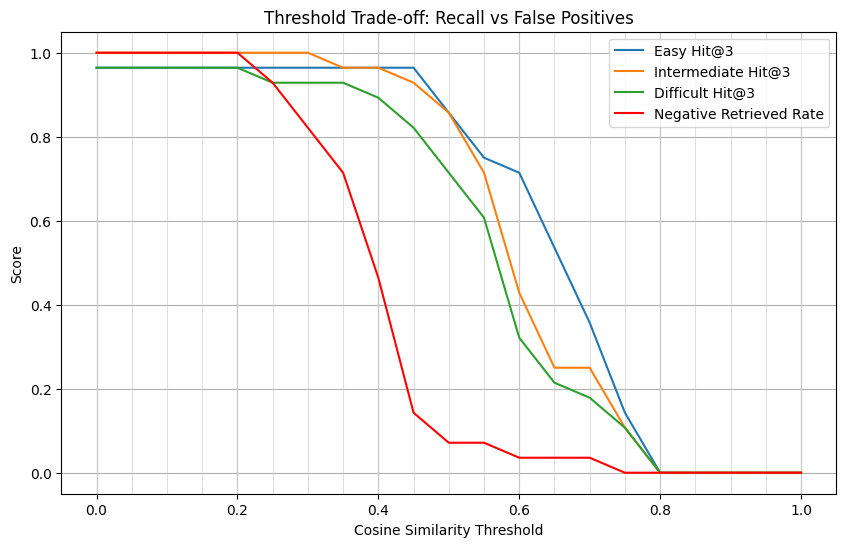

In [ ]:
threshold_selection_plot(thresholds, df_metrics)

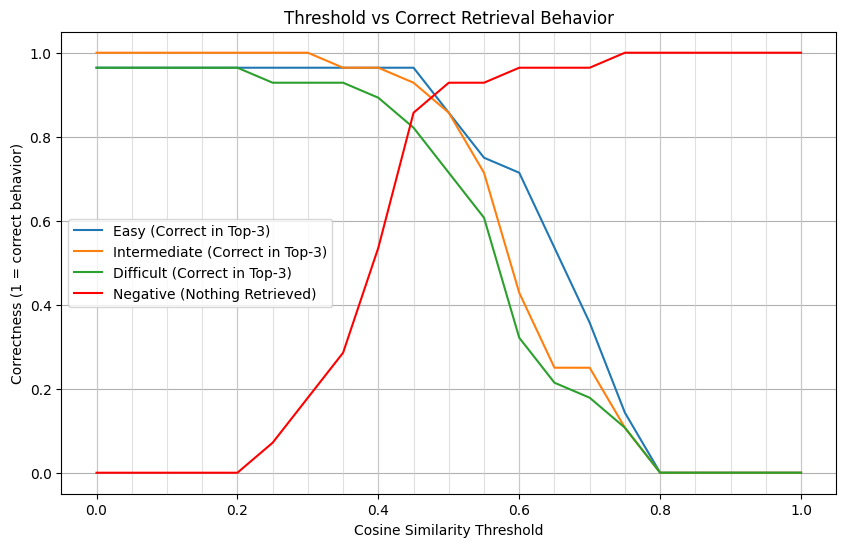

In [ ]:
threshold_selection_plot(thresholds, df_metrics, False)

#### Precision.recall

In [ ]:
plt.figure(figsize=(7, 6))
plt.plot(df_metrics["Recall"], df_metrics["Precision"], marker="o")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [62]:
thresholds_detailed = [0, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.50, 1]
df_metrics_detailed = sweep_thresholds(final_retriever, thresholds, query_sets)

0% processed...
10% processed...
20% processed...
30% processed...
40% processed...
50% processed...
60% processed...
70% processed...
80% processed...
90% processed...
100% processed...


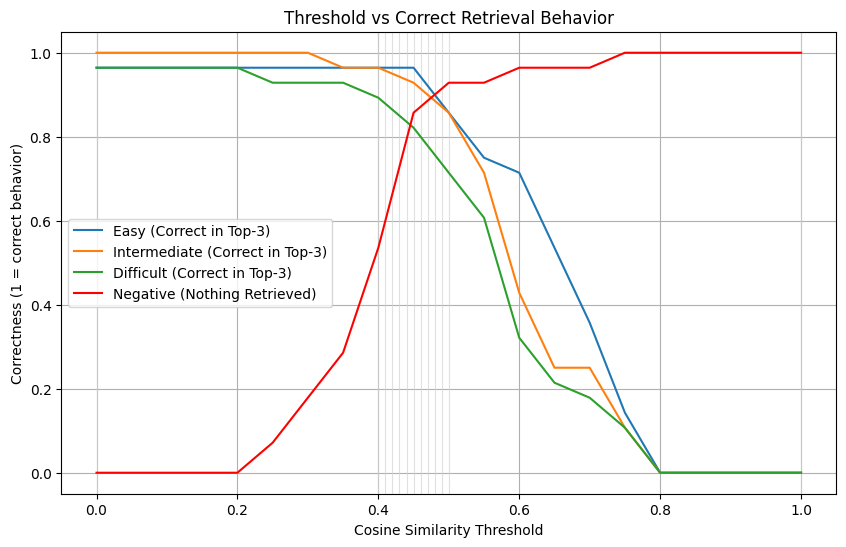

In [ ]:
threshold_selection_plot(thresholds_detailed, df_metrics_detailed)

#### conf matrix

In [ ]:
best_threshold = 0.45
row = df_metrics[df_metrics["Threshold"] == best_threshold].iloc[0]

cm = [[row["TN"], row["FP"]],
      [row["FN"], row["TP"]]]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Retrieval", "Retrieved"])

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix @ Threshold={best_threshold}")
plt.show()